In [ ]:
import numpy as np

In [3]:
import mcstasscript as ms


In [4]:
configurator = ms.Configurator()
configurator.set_mcrun_path("/usr/bin/")
configurator.set_mcstas_path("/usr/share/mcstas/resources/")
print(configurator)

Configurator:
 paths:
  mcrun_path: /usr/bin/
  mcstas_path: /usr/share/mcstas/resources/
  mcxtrace_path: /Applications/McXtrace-1.5.app/Contents/Resources/mcxtrace/1.5/
  mxrun_path: /Applications/McXtrace-1.5.app/Contents/Resources/mcxtrace/1.5/bin/
 other:
  characters_per_line: 85



In [5]:
pip install pytest

Note: you may need to restart the kernel to use updated packages.


In [6]:
instrument = ms.McStas_instr("NSM_instrument_1")

In [7]:
instrument.available_components()

Here are the available component categories:
 contrib
 misc
 monitors
 obsolete
 optics
 samples
 sasmodels
 sources
 union
Call available_components(category_name) to display


In [8]:
instrument.available_components("sources")

Here are all components in the sources category.
 Adapt_check     Monitor_Optimizer   Source_adapt       Source_simple
 ESS_butterfly   Source_4PI          Source_div         
 ESS_moderator   Source_Maxwell_3    Source_div_quasi   
 Moderator       Source_Optimizer    Source_gen         


In [ ]:
monitornf swiss army monitor, 

In [9]:
source = instrument.add_component("source", "Source_simple")
source.show_parameters()

 ___ Help Source_simple _____________________________________________________________
|optional parameter|required parameter|default value|user specified value|
radius = 0.1 [m] // Radius of circle in (x,y,0) plane where neutrons are 
                    generated. 
yheight = 0.0 [m] // Height of rectangle in (x,y,0) plane where neutrons are 
                     generated. 
xwidth = 0.0 [m] // Width of rectangle in (x,y,0) plane where neutrons are 
                    generated. 
dist = 0.0 [m] // Distance to target along z axis.
focus_xw = 0.045 [m] // Width of target
focus_yh = 0.12 [m] // Height of target
E0 = 0.0 [meV] // Mean energy of neutrons.
dE = 0.0 [meV] // Energy half spread of neutrons (flat or gaussian sigma).
lambda0 = 0.0 [AA] // Mean wavelength of neutrons.
dlambda = 0.0 [AA] // Wavelength half spread of neutrons.
flux = 1.0 [1/(s*cm**2*st*energy unit)] // flux per energy unit, Angs or meV if 
                                           flux=0, the source emits 1 in 4*

In [63]:
wavelength = instrument.add_parameter("wavelength", value=3, comment="Wavelength in AA")
source.lambda0 = wavelength
print(source)

COMPONENT source = Source_gen(
  lambda0 = wavelength // [AA]
)
AT (0, 0, 0) ABSOLUTE


In [64]:
delta_wavelength = instrument.add_parameter("delta_wavelength", value=0.3, comment="delta_Wavelength in AA")
source.dlambda = "delta_wavelength"
print(source)

COMPONENT source = Source_gen(
  lambda0 = wavelength, // [AA]
  dlambda = delta_wavelength // [AA]
)
AT (0, 0, 0) ABSOLUTE


In [65]:
source.xwidth = 0.135
source.yheight = 0.08
source.dist = 0.79045+0.39063
source.focus_xw = 0.11
source.focus_yh = 0.11
source.T1 = 361.9
source.I1 = 7.22e12 
source.T2 = 159.0
source.I2 = 6.74e12
source.T3 = 35.66
source.I3 = 6.435e12
print(source)

COMPONENT source = Source_gen(
  dist = 1.18108, // [m]
  focus_xw = 0.11, // [m]
  focus_yh = 0.11, // [m]
  lambda0 = wavelength, // [AA]
  dlambda = delta_wavelength, // [AA]
  I1 = 7220000000000.0, // [1/(cm**2*sr)]
  yheight = 0.08, // [m]
  xwidth = 0.135, // [m]
  T1 = 361.9, // [K]
  T2 = 159.0, // [K]
  I2 = 6740000000000.0, // [1/(cm**2*sr)]
  T3 = 35.66, // [K]
  I3 = 6435000000000.0 // [1/(cm**2*sr)]
)
AT (0, 0, 0) ABSOLUTE


In [66]:

PSD_1 = instrument.add_component("PSD_1", "PSD_monitor")
PSD_1.show_parameters()
PSD_1.set_AT([0, 0, 0.01], RELATIVE=source)

 ___ Help PSD_monitor _______________________________________________________________
|optional parameter|required parameter|default value|user specified value|
nx = 90 [1] // Number of pixel columns
ny = 90 [1] // Number of pixel rows
filename = 0 [string] // Name of file in which to store the detector image
xmin = -0.05 [m] // Lower x bound of detector opening
xmax = 0.05 [m] // Upper x bound of detector opening
ymin = -0.05 [m] // Lower y bound of detector opening
ymax = 0.05 [m] // Upper y bound of detector opening
xwidth = 0.0 [m] // Width of detector. Overrides xmin, xmax
yheight = 0.0 [m] // Height of detector. Overrides ymin, ymax
restore_neutron = 0 [1] // If set, the monitor does not influence the neutron 
                           state 
nowritefile = 0 [1] // If set, monitor will skip writing to disk
-------------------------------------------------------------------------------------


In [67]:
PSD_1.set_parameters(xmin=-0.04, xmax=0.04, ymin=-0.10, ymax=0.10,nx=80,ny=200, filename='"PSD_1.dat"', restore_neutron=1)
print(PSD_1)

COMPONENT PSD_1 = PSD_monitor(
  nx = 80, // [1]
  ny = 200, // [1]
  filename = "PSD_1.dat", // [string]
  xmin = -0.04, // [m]
  xmax = 0.04, // [m]
  ymin = -0.1, // [m]
  ymax = 0.1, // [m]
  restore_neutron = 1 // [1]
)
AT (0, 0, 0.01) RELATIVE source


In [68]:
instrument.available_components("optics")

Here are all components in the optics category.
 Absorber                 Guide_channeled        Pol_FieldBox
 Arm                      Guide_gravity          Pol_SF_ideal
 Beamstop                 Guide_simple           Pol_bender
 Bender                   Guide_tapering         Pol_constBfield
 Collimator_linear        Guide_wavy             Pol_guide_mirror
 Collimator_radial        He3_cell               Pol_guide_vmirror
 Derotator                Mask                   Pol_mirror
 Diaphragm                Mirror                 Pol_tabled_field
 DiskChopper              Monochromator_curved   Refractor
 Elliptic_guide_gravity   Monochromator_flat     Rotator
 FZP_simple               Monochromator_pol      Selector
 FermiChopper             Place                  Set_pol
 Filter_gen               PolAnalyser_ideal      Slit
 Guide                    Pol_Bfield             V_selector
 Guide_anyshape           Pol_Bfield_stop        Vitess_ChopperFermi


In [69]:
NL_SR2_1= instrument.add_component("optics", "Guide_gravity")
NL_SR2_1.show_parameters()

 ___ Help Guide_gravity _____________________________________________________________
|optional parameter|required parameter|default value|user specified value|
w1 [m] // Width at the guide entry
h1 [m] // Height at the guide entry
w2 = 0.0 [m] // Width at the guide exit. If 0, use w1.
h2 = 0.0 [m] // Height at the guide exit. If 0, use h1.
l [m] // length of guide
R0 = 0.995 [1] // Low-angle reflectivity
Qc = 0.0218 [AA-1] // Critical scattering vector
alpha = 4.38 [AA] // Slope of reflectivity
m = 1.0 [1] // m-value of material. Zero means completely absorbing. m=0.65  
               glass/SiO2 Si   Ni  Ni58  supermirror Be    Diamond m=  0.65       
               0.47 1   1.18  2-6         1.01  1.12 for glass/SiO2, m=1 for Ni, 
               1.2 for Ni58, m=2-6 for supermirror. m=0.47 for Si 
W = 0.003 [AA-1] // Width of supermirror cut-off
nslit = 1.0 [1] // Number of vertical channels in the guide (>= 1) (nslit-1 
                   vertical dividing walls). 
d = 0.0005 [m] //

In [70]:

NL_SR2_1.w1 = 0.105
NL_SR2_1.h1 = 0.098
NL_SR2_1.w2 = 0.105
NL_SR2_1.h2 = 0.118
NL_SR2_1.R0 = 0.995
NL_SR2_1.Qc = 0.02174
NL_SR2_1.l=1.307
NL_SR2_1.alpha = 4.38
NL_SR2_1.W = 0.0009
NL_SR2_1.nslit = 1
NL_SR2_1.mleft = 1.0
NL_SR2_1.mright = 1.0
NL_SR2_1.mtop = 1.0
NL_SR2_1.mbottom = 1.0

In [71]:
NL_SR2_1.set_AT([0, 0, 1.18108], RELATIVE=source)
print(NL_SR2_1)

COMPONENT optics = Guide_gravity(
  w1 = 0.105, // [m]
  h1 = 0.098, // [m]
  w2 = 0.105, // [m]
  h2 = 0.118, // [m]
  l = 1.307, // [m]
  R0 = 0.995, // [1]
  Qc = 0.02174, // [AA-1]
  alpha = 4.38, // [AA]
  W = 0.0009, // [AA-1]
  nslit = 1, // [1]
  mleft = 1.0, // [1]
  mright = 1.0, // [1]
  mtop = 1.0, // [1]
  mbottom = 1.0 // [1]
)
AT (0, 0, 1.18108) RELATIVE source


In [72]:
instrument.show_parameters()

 wavelength        = 3    // Wavelength in AA
 delta_wavelength  = 0.3  // delta_Wavelength in AA


In [73]:
instrument.set_parameters(wavelength=4.8, delta_wavelength=0.01)
instrument.settings(ncount=2E6)

In [74]:
print(instrument.__dict__)

{'particle': 'neutron', 'package_name': 'McStas', '_BaseCalculator__name': 'NSM_instrument_1', '_BaseCalculator__instrument_base_dir': './', '_BaseCalculator__calculator_base_dir': 'NSM_instrument_1', '_BaseCalculator__input': <libpyvinyl.BaseData.DataCollection object at 0x79b5b12b62c0>, '_BaseCalculator__output_keys': ['NSM_instrument_1_data'], '_BaseCalculator__output_data_types': [<class 'mcstasscript.data.pyvinylData.pyvinylMcStasData'>], '_BaseCalculator__output_filenames': [None], '_BaseCalculator__parameters':  - Parameters object -
wavelength                          4.8                             Wavelength in AA   
delta_wavelength                    0.01                            delta_Wavelength in AA   
, '_BaseCalculator__output': <libpyvinyl.BaseData.DataCollection object at 0x79b5b143a8d0>, 'author': 'Python McStas Instrument Generator', 'origin': 'ESS DMSC', '_run_settings': {'executable_path': '/usr/bin', 'package_path': '/usr/share/mcstas/resources', 'run_path': '

In [75]:
NL_SR2_2a = instrument.add_component("NL_SR2_2a", "Guide_gravity")


In [76]:
NL_SR2_2a.show_parameters()
NL_SR2_2a.set_AT([0, 0, 2.540], RELATIVE=source)
NL_SR2_2a.set_parameters(w1=0.106, h1=0.119,
                         w2=0.106, h2=0.134,
                         l=0.997, R0=0.99,
                         Qc=0.02174, alpha=3.0, 
                         W=0.001, nslit=1, 
                         mleft=3.0, mright=3.0, mtop=0, mbottom=0)

 ___ Help Guide_gravity _____________________________________________________________
|optional parameter|required parameter|default value|user specified value|
w1 [m] // Width at the guide entry
h1 [m] // Height at the guide entry
w2 = 0.0 [m] // Width at the guide exit. If 0, use w1.
h2 = 0.0 [m] // Height at the guide exit. If 0, use h1.
l [m] // length of guide
R0 = 0.995 [1] // Low-angle reflectivity
Qc = 0.0218 [AA-1] // Critical scattering vector
alpha = 4.38 [AA] // Slope of reflectivity
m = 1.0 [1] // m-value of material. Zero means completely absorbing. m=0.65  
               glass/SiO2 Si   Ni  Ni58  supermirror Be    Diamond m=  0.65       
               0.47 1   1.18  2-6         1.01  1.12 for glass/SiO2, m=1 for Ni, 
               1.2 for Ni58, m=2-6 for supermirror. m=0.47 for Si 
W = 0.003 [AA-1] // Width of supermirror cut-off
nslit = 1.0 [1] // Number of vertical channels in the guide (>= 1) (nslit-1 
                   vertical dividing walls). 
d = 0.0005 [m] //

In [77]:
NL_SR2_2_3 = instrument.add_component("NL_SR2_2_3", "Guide_gravity")


In [78]:
NL_SR2_2_3.show_parameters()
NL_SR2_2_3.set_AT([0, 0, 3.546], RELATIVE=source)
NL_SR2_2_3.set_parameters(w1=0.107, h1=0.135,
                          w2=0.107, h2=0.138,
                          l=0.180, R0=0.99,
                          Qc=0.02174, alpha=3.0, 
                         W=0.001, nslit=1, 
                         mleft=2.0, mright=2.0, mtop=0, mbottom=0)

 ___ Help Guide_gravity _____________________________________________________________
|optional parameter|required parameter|default value|user specified value|
w1 [m] // Width at the guide entry
h1 [m] // Height at the guide entry
w2 = 0.0 [m] // Width at the guide exit. If 0, use w1.
h2 = 0.0 [m] // Height at the guide exit. If 0, use h1.
l [m] // length of guide
R0 = 0.995 [1] // Low-angle reflectivity
Qc = 0.0218 [AA-1] // Critical scattering vector
alpha = 4.38 [AA] // Slope of reflectivity
m = 1.0 [1] // m-value of material. Zero means completely absorbing. m=0.65  
               glass/SiO2 Si   Ni  Ni58  supermirror Be    Diamond m=  0.65       
               0.47 1   1.18  2-6         1.01  1.12 for glass/SiO2, m=1 for Ni, 
               1.2 for Ni58, m=2-6 for supermirror. m=0.47 for Si 
W = 0.003 [AA-1] // Width of supermirror cut-off
nslit = 1.0 [1] // Number of vertical channels in the guide (>= 1) (nslit-1 
                   vertical dividing walls). 
d = 0.0005 [m] //

In [79]:
SR2_Beamportwindow= instrument.add_component("SR2_Beamportwindow", "Al_window")


In [80]:
SR2_Beamportwindow.show_parameters()
SR2_Beamportwindow.set_AT([0, 0, 3.81], RELATIVE=source)
SR2_Beamportwindow.set_parameters(thickness=0.003)

 ___ Help Al_window _________________________________________________________________
|optional parameter|required parameter|default value|user specified value|
thickness = 0.001 [m] // Al Window thickness
-------------------------------------------------------------------------------------


In [81]:
SR2_eob= instrument.add_component("SR2_eob", "Arm")

In [82]:

SR2_eob.set_AT([0,0,0.0031], RELATIVE= 'SR2_Beamportwindow')
SR2_eob.set_ROTATED([0,0,0], RELATIVE= 'SR2_Beamportwindow')

In [83]:
PANDA_ca1= instrument.add_component("PANDA_ca1", "Collimator_linear")

In [84]:
PANDA_ca1.show_parameters()
PANDA_ca1.set_parameters(xwidth=0.108, yheight=0.160, divergence=80, length=0.50, transmission=1)
PANDA_ca1.set_AT([0,0,0.1000], RELATIVE= 'SR2_eob')

 ___ Help Collimator_linear _________________________________________________________
|optional parameter|required parameter|default value|user specified value|
xmin = -0.02 [m] // Lower x bound on slits
xmax = 0.02 [m] // Upper x bound on slits
ymin = -0.05 [m] // Lower y bound on slits
ymax = 0.05 [m] // Upper y bound on slits
xwidth = 0.0 [m] // Width of slits
yheight = 0.0 [m] // Height of slits
length = 0.3 [m] // Distance between input and output slits
divergence = 40.0 [minutes of arc] // Divergence horizontal angle (calculated 
                                      as atan(d/length), where d is the blade 
                                      spacing) 
transmission = 1.0 [1] // Transmission of Soller (0<=t<=1)
divergenceV = 0.0 [minutes of arc] // Divergence vertical angle
-------------------------------------------------------------------------------------


In [85]:
PANDA_sapphire = instrument.add_component("PANDA_sapphire", "Filter_gen")


In [86]:
PANDA_sapphire.set_parameters(filename = '"Al2O3_sapphire.trm"', thickness = 0.86)
PANDA_sapphire.show_parameters()
PANDA_sapphire.set_AT([0,0,0.9000], RELATIVE= 'SR2_eob')

 ___ Help Filter_gen ________________________________________________________________
|optional parameter|required parameter|default value|user specified value|
filename = "Al2O3_sapphire.trm"
options = 0
xmin = -0.05
xmax = 0.05
ymin = -0.05
ymax = 0.05
xwidth = 0.0
yheight = 0.0
thickness = 0.86
scaling = 1.0
verbose = 0.0
-------------------------------------------------------------------------------------


In [87]:
PANDA_sapphire.show_parameters

<bound method Component.show_parameters of COMPONENT PANDA_sapphire = Filter_gen(
  filename = "Al2O3_sapphire.trm",
  thickness = 0.86
)
AT (0, 0, 0.9) RELATIVE SR2_eob>

In [88]:
sk1_in= instrument.add_component("sk1_in", "Slit")

In [89]:
sk1_in.show_parameters()
sk1_in.set_parameters(xwidth=0.11, yheight=0.15)
sk1_in.set_AT([0,0,1.0100], RELATIVE= 'SR2_eob')

 ___ Help Slit ______________________________________________________________________
|optional parameter|required parameter|default value|user specified value|
xmin = UNSET [m] // Lower x bound
xmax = UNSET [m] // Upper x bound
ymin = UNSET [m] // Lower y bound
ymax = UNSET [m] // Upper y bound
radius = UNSET [m] // Radius of slit in the z=0 plane, centered at Origin
xwidth = UNSET [m] // Width of slit. Overrides xmin,xmax if they are unset.
yheight = UNSET [m] // Height of slit. Overrides ymin,ymax if they are unset.
-------------------------------------------------------------------------------------


In [90]:
sk1_out= instrument.add_component("sk1_out", "Slit")

In [91]:
sk1_out.show_parameters()
sk1_out.set_parameters(xwidth=0.09, yheight=0.180)
sk1_out.set_AT([0,0,2.0300], RELATIVE= 'SR2_eob')

 ___ Help Slit ______________________________________________________________________
|optional parameter|required parameter|default value|user specified value|
xmin = UNSET [m] // Lower x bound
xmax = UNSET [m] // Upper x bound
ymin = UNSET [m] // Lower y bound
ymax = UNSET [m] // Upper y bound
radius = UNSET [m] // Radius of slit in the z=0 plane, centered at Origin
xwidth = UNSET [m] // Width of slit. Overrides xmin,xmax if they are unset.
yheight = UNSET [m] // Height of slit. Overrides ymin,ymax if they are unset.
-------------------------------------------------------------------------------------


In [92]:
PSD = instrument.add_component("PSD", "PSD_monitor")
PSD.show_parameters()


 ___ Help PSD_monitor _______________________________________________________________
|optional parameter|required parameter|default value|user specified value|
nx = 90 [1] // Number of pixel columns
ny = 90 [1] // Number of pixel rows
filename = 0 [string] // Name of file in which to store the detector image
xmin = -0.05 [m] // Lower x bound of detector opening
xmax = 0.05 [m] // Upper x bound of detector opening
ymin = -0.05 [m] // Lower y bound of detector opening
ymax = 0.05 [m] // Upper y bound of detector opening
xwidth = 0.0 [m] // Width of detector. Overrides xmin, xmax
yheight = 0.0 [m] // Height of detector. Overrides ymin, ymax
restore_neutron = 0 [1] // If set, the monitor does not influence the neutron 
                           state 
nowritefile = 0 [1] // If set, monitor will skip writing to disk
-------------------------------------------------------------------------------------


In [93]:
PSD.set_AT([0, 0, 0.001], RELATIVE='sk1_out')
PSD.set_parameters(xmin=-0.05, xmax=0.05, ymin=-0.11, ymax=0.11,nx=80,ny=200, filename='"PSD.dat"', restore_neutron=1)
print(PSD)

COMPONENT PSD = PSD_monitor(
  nx = 80, // [1]
  ny = 200, // [1]
  filename = "PSD.dat", // [string]
  xmin = -0.05, // [m]
  xmax = 0.05, // [m]
  ymin = -0.11, // [m]
  ymax = 0.11, // [m]
  restore_neutron = 1 // [1]
)
AT (0, 0, 0.001) RELATIVE sk1_out


In [ ]:
DIV= instrument.add_component("DIV", "Divergence_monitor")

In [96]:
DIV.set_parameters(xmin=-0.04, xmax=0.04, ymin=-0.15, ymax=0.15,
                   maxdiv_h= 2, maxdiv_v=2, nh =40, nv =40, restore_neutron=1)
DIV.set_AT([0, 0, 0.0001], RELATIVE='sk1_out')
print(DIV)

COMPONENT DIV = Divergence_monitor(
  nh = 40, // [1]
  nv = 40, // [1]
  xmin = -0.04, // [m]
  xmax = 0.04, // [m]
  ymin = -0.15, // [m]
  ymax = 0.15, // [m]
  maxdiv_h = 2, // [degrees]
  maxdiv_v = 2, // [degrees]
  restore_neutron = 1 // [1]
)
AT (0, 0, 0.0001) RELATIVE sk1_out


In [97]:
print(instrument.__dict__)

{'particle': 'neutron', 'package_name': 'McStas', '_BaseCalculator__name': 'NSM_instrument_1', '_BaseCalculator__instrument_base_dir': './', '_BaseCalculator__calculator_base_dir': 'NSM_instrument_1', '_BaseCalculator__input': <libpyvinyl.BaseData.DataCollection object at 0x79b5b12b62c0>, '_BaseCalculator__output_keys': ['NSM_instrument_1_data'], '_BaseCalculator__output_data_types': [<class 'mcstasscript.data.pyvinylData.pyvinylMcStasData'>], '_BaseCalculator__output_filenames': [None], '_BaseCalculator__parameters':  - Parameters object -
wavelength                          4.8                             Wavelength in AA   
delta_wavelength                    0.01                            delta_Wavelength in AA   
, '_BaseCalculator__output': <libpyvinyl.BaseData.DataCollection object at 0x79b5b143a8d0>, 'author': 'Python McStas Instrument Generator', 'origin': 'ESS DMSC', '_run_settings': {'executable_path': '/usr/bin', 'package_path': '/usr/share/mcstas/resources', 'run_path': '

In [98]:
data = instrument.backengine()


INFO: Using directory: "/mnt/c/Users/Sierra_Manrique/Desktop/PANDA/NSM_instrument_1_7"
INFO: Regenerating c-file: NSM_instrument_1.c
Info:    'Al_window' is a contributed component.
CFLAGS=
      
-----------------------------------------------------------

Generating single GPU kernel or single CPU section layout: 

-----------------------------------------------------------

Generating GPU/CPU -DFUNNEL layout:

-----------------------------------------------------------
INFO: Recompiling: ./NSM_instrument_1.out
lto-wrapper: warning: using serial compilation of 2 LTRANS jobs
lto-wrapper: note: see the ‘-flto’ option documentation for more information
INFO: ===
Al_window SR2_Beamportwindow WARNING: Using simple lo-fi transmission model.
 - Replace with PowderN or NCrystal for bragg edges etc.
Opening input file 'Al2O3_sapphire.trm' (Table_Read_Offset)
*** TRACE end *** 
Detector: PSD_1_I=1.4568e+10 PSD_1_ERR=1.33271e+07 PSD_1_N=1.19492e+06 "PSD_1.dat"
Detector: PSD_I=5.78135e+08 PSD_E

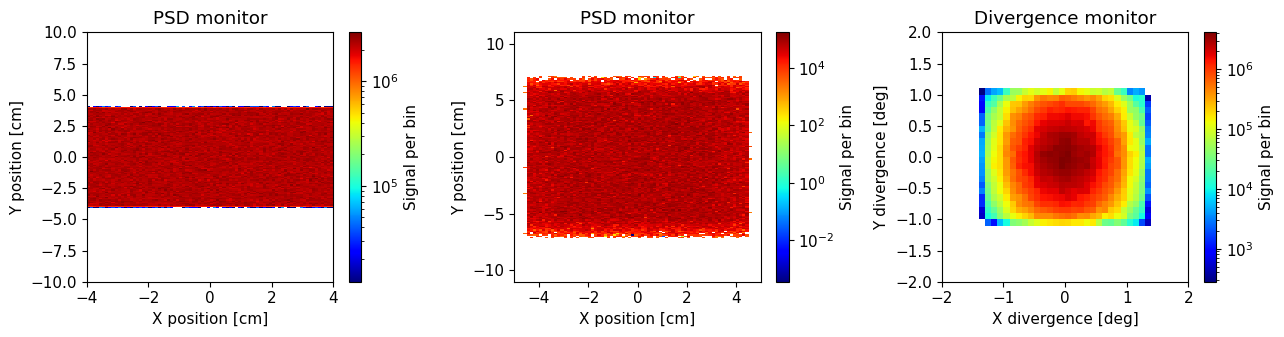

In [99]:
ms.make_sub_plot(data, log=True)